In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45, 0.15]
}

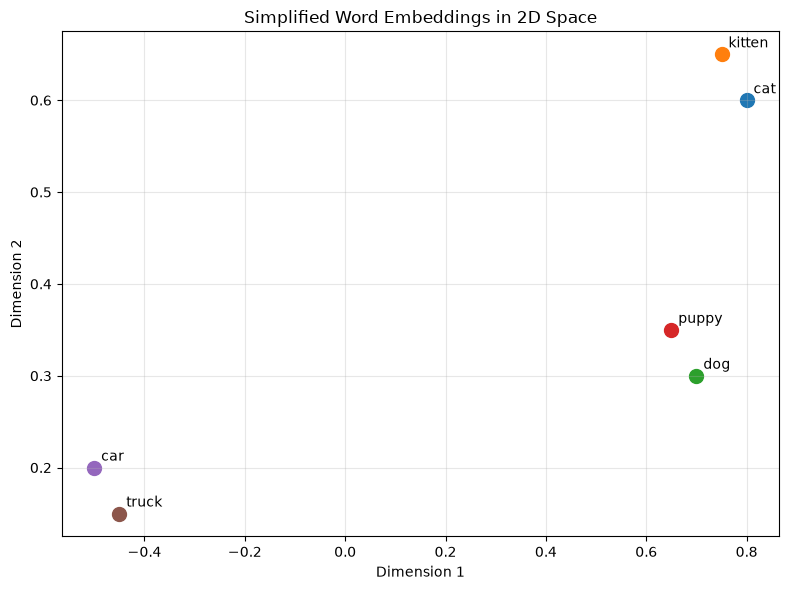

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

for word, coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1], s=100)
    ax.annotate(word, (coords[0], coords[1]), xytext=(5, 5), 
                textcoords='offset points')

ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Simplified Word Embeddings in 2D Space')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
def cosine_similarity(vec1, vec2):
    """
    Cosine similarity measures the angle between two vectors.
    - Result close to 1: Very similar
    - Result close to 0: Not related
    - Result close to -1: Opposite meanings
    """

    dot_product=np.dot(vec1,vec2)
    norm_a=np.linalg.norm(vec1)
    norm_b=np.linalg.norm(vec2)
    return dot_product/(norm_a * norm_b)

In [5]:
cat_vector = [0.8, 0.6, 0.3]
kitten_vector = [0.75, 0.65, 0.35]
car_vector = [-0.5, 0.2, 0.1]

cat_kitten_similarity=cosine_similarity(cat_vector,kitten_vector)
print(cat_kitten_similarity)

0.9966186334192181


In [6]:
cosine_similarity(cat_vector,car_vector)

np.float64(-0.43718588548916804)

In [8]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings=HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
embeddings

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5193.59it/s]


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [9]:
text="Hello, I am learning about embeddings!"

embedding=embeddings.embed_query(text)
print(f"Text: {text}")
print(f"Embedding length : {len(embedding)}")
print(embedding)

Text: Hello, I am learning about embeddings!
Embedding length : 384
[-0.01816326379776001, -0.09955169260501862, 0.013816027902066708, -0.00812597293406725, 0.01415228471159935, 0.0640648677945137, -0.006253377068787813, -0.003017888404428959, 0.025287209078669548, -0.02019863948225975, 0.02432972751557827, 0.07435064017772675, 0.05117722973227501, 0.02203851193189621, -0.05830617621541023, 0.01526821218430996, 0.023584362119436264, 0.09455390274524689, -0.06508845090866089, 0.013296646066009998, -0.020497558638453484, -0.05690857768058777, 0.03030332177877426, -0.08365609496831894, 0.026596298441290855, -0.015231452882289886, -0.04361540079116821, 0.05398401618003845, 0.09025716781616211, -0.08893883973360062, 0.03964461758732796, -0.008835024200379848, -0.03034374490380287, 0.07425564527511597, -0.0540991947054863, 0.11107997596263885, 0.036899879574775696, -0.008959847502410412, -0.06140241026878357, -0.0031433829572051764, 0.021958177909255028, 0.04220819100737572, -0.0289378669112

In [11]:
sentences = [
    "The cat sat on the mat",
    "The rat sat on the mat",
    "The dog played in the yard",
    "I love programming in Python",
    "Python is my favorite programming language"
]

embedding_sentence=embeddings.embed_documents(sentences)

print(embedding_sentence[0])
print(embedding_sentence[1])

[0.1304018348455429, -0.01187008898705244, -0.02811703085899353, 0.05123864859342575, -0.055974479764699936, 0.03019154630601406, 0.030161265283823013, 0.02469840832054615, -0.01837059296667576, 0.05876680463552475, -0.024953173473477364, 0.0601542629301548, 0.039831776171922684, 0.033230509608983994, -0.06131136044859886, -0.04937314614653587, -0.05486352741718292, -0.040076058357954025, 0.056429117918014526, 0.03915657475590706, -0.03473714366555214, -0.013247663155198097, 0.031966231763362885, -0.06349924206733704, -0.06017862260341644, 0.07823451608419418, -0.028303898870944977, -0.047442857176065445, 0.040359288454055786, -0.006630914285778999, -0.0667409673333168, -0.004191394429653883, -0.025311686098575592, 0.05334167927503586, 0.01742812804877758, -0.09792362153530121, 0.006061307154595852, -0.06524164229631424, 0.045572590082883835, 0.02364179864525795, 0.0765848234295845, -0.01026437059044838, -0.004076848272234201, -0.062322795391082764, 0.03370528295636177, 0.0186610929667